In [1]:
# Run this once (if using Colab, it's already installed)
%pip install seaborn pandas matplotlib numpy  # Skip if already installed


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make charts look clean and professional
sns.set_style("whitegrid")      # Clean background
sns.set_palette("viridis")      # Nice color scheme
plt.rcParams['figure.figsize'] = (10, 6)  # Default chart size

print("✅ Seaborn ready!")

✅ Seaborn ready!


In [3]:
# Synthetic data for Mumbai West (realistic prices & areas)
np.random.seed(42)  # For reproducible results

locations = ['Andheri West', 'Bandra West', 'Juhu', 'Santacruz West', 'Khar West', 'Bandra East', 'Versova']

data = {
    'BHK': np.random.choice([1, 2, 3, 4], 800, p=[0.15, 0.45, 0.3, 0.1]),
    'Locality': np.random.choice(locations, 800),
    'Area_sqft': np.random.normal(1100, 350, 800).astype(int).clip(600, 2500),
    'Price_Lakhs': np.random.normal(450, 280, 800).astype(int).clip(100, 3000),
    'Status': np.random.choice(['Ready to Move', 'Under Construction'], 800),
    'Age': np.random.choice(['0-1 Year', '1-5 Years', '5-10 Years', '10+ Years'], 800)
}

df = pd.DataFrame(data)

# Make prices realistic (premium areas cost more)
premium = ['Bandra West', 'Juhu', 'Khar West']
df.loc[df['Locality'].isin(premium), 'Price_Lakhs'] += 200
df['Price_Lakhs'] = (df['Price_Lakhs'] + (df['Area_sqft'] * 0.4) + (df['BHK'] * 80)).astype(int).clip(100, 3000)
df.to_csv('mumbai_west_housing.csv', index=False)
print("✅ Dataset ready! Shape:", df.shape)
print(df.head())  # Peek at first 5 rows

✅ Dataset ready! Shape: (800, 6)
   BHK        Locality  Area_sqft  Price_Lakhs              Status         Age
0    2         Versova       1231         1176       Ready to Move   1-5 Years
1    4     Bandra West        834         1482       Ready to Move  5-10 Years
2    3    Andheri West        624         1121  Under Construction  5-10 Years
3    2  Santacruz West        989         1757       Ready to Move  5-10 Years
4    2         Versova        840          596       Ready to Move  5-10 Years


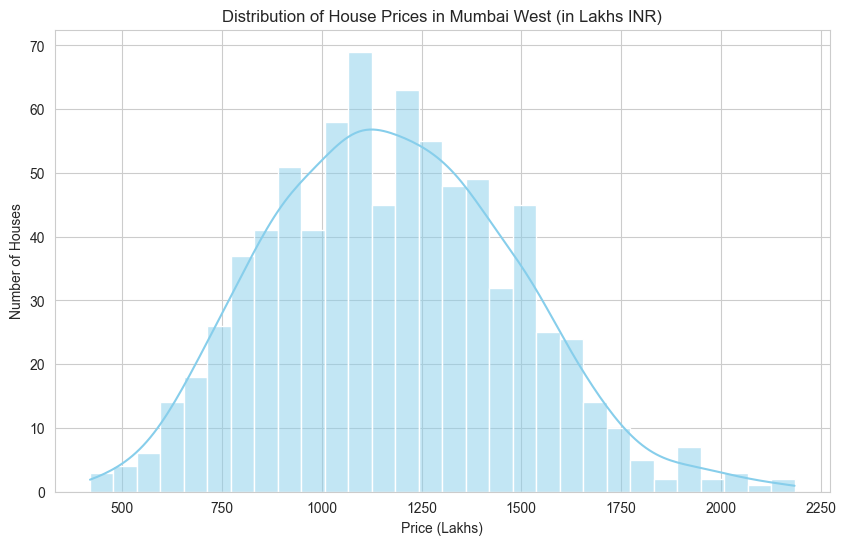

In [4]:
# Step 3: Basic Distribution – How are prices spread out?
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price_Lakhs', kde=True, bins=30, color='skyblue')
plt.title('Distribution of House Prices in Mumbai West (in Lakhs INR)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Number of Houses')
plt.show()

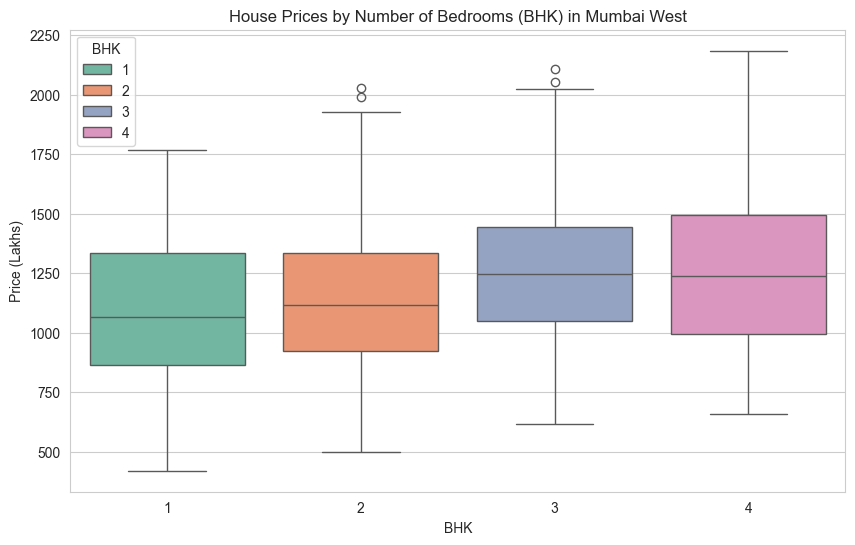

In [6]:
# Step 4: Compare Prices by BHK (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='BHK', y='Price_Lakhs', palette='Set2' , hue='BHK')
plt.title('House Prices by Number of Bedrooms (BHK) in Mumbai West')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

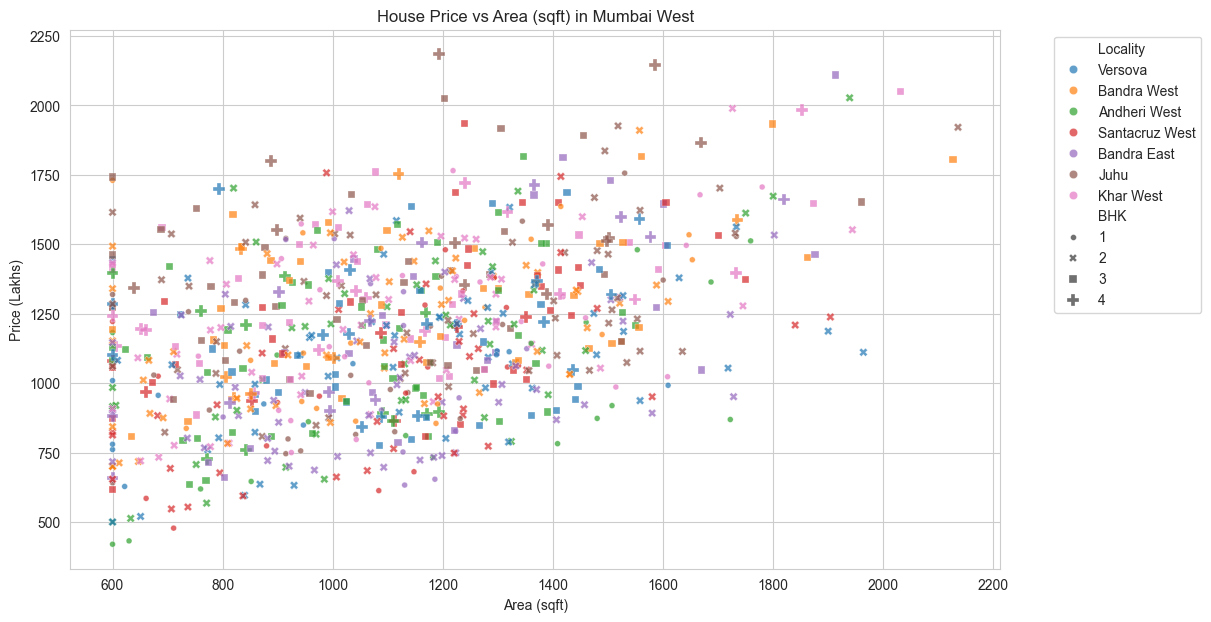

In [7]:
# Step 5: Relationship – Price vs Area (Scatterplot)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Area_sqft', y='Price_Lakhs', 
                hue='Locality', style='BHK', size='BHK', 
                palette='tab10', alpha=0.7)
plt.title('House Price vs Area (sqft) in Mumbai West')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

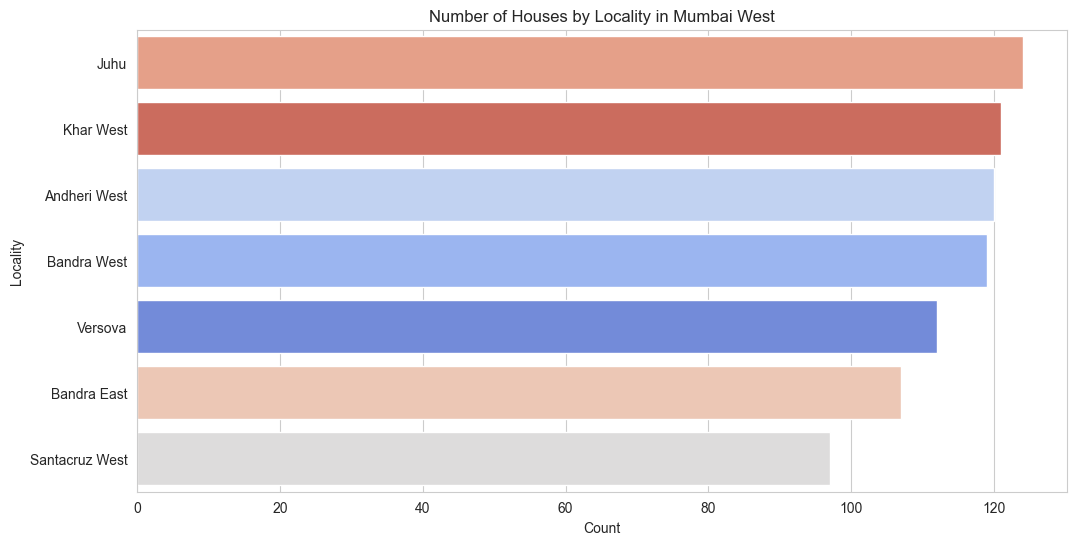

In [9]:
### Step 6: Count of Houses by Locality (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Locality', 
              order=df['Locality'].value_counts().index, 
              palette='coolwarm',hue='Locality')
plt.title('Number of Houses by Locality in Mumbai West')
plt.xlabel('Count')
plt.ylabel('Locality')
plt.show()

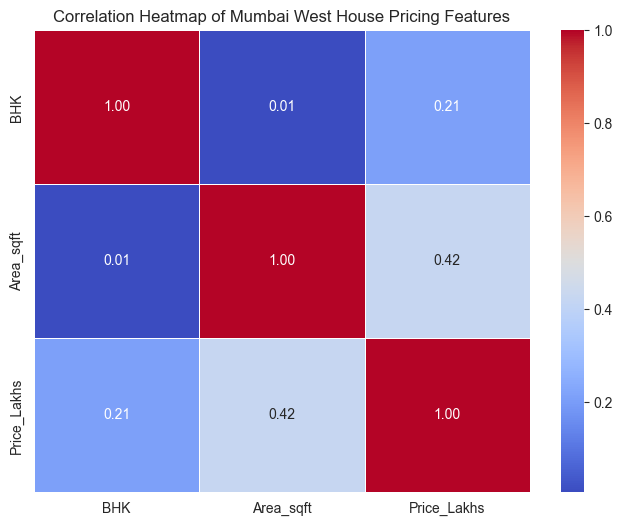

In [ ]:
### Step 7: Correlation Heatmap – See relationships at a glance
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Mumbai West House Pricing Features')
plt.show()

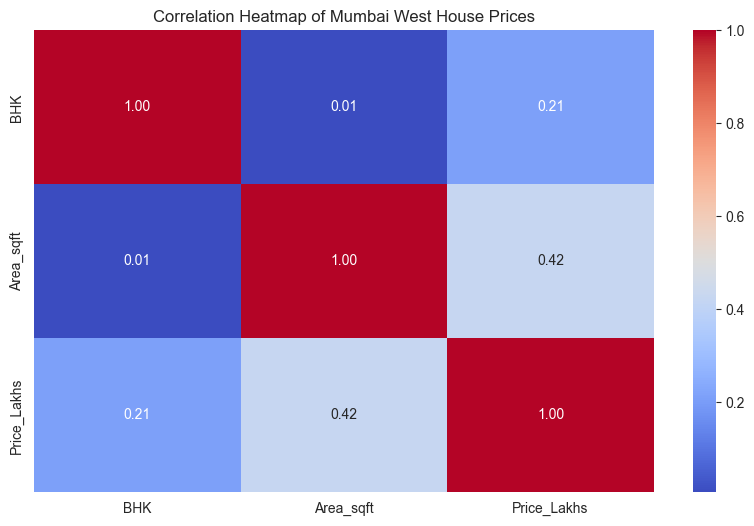

In [11]:
# How we created it
numeric_data = df[['BHK', 'Area_sqft', 'Price_Lakhs']]   # Only number columns
corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Mumbai West House Prices')
plt.show()

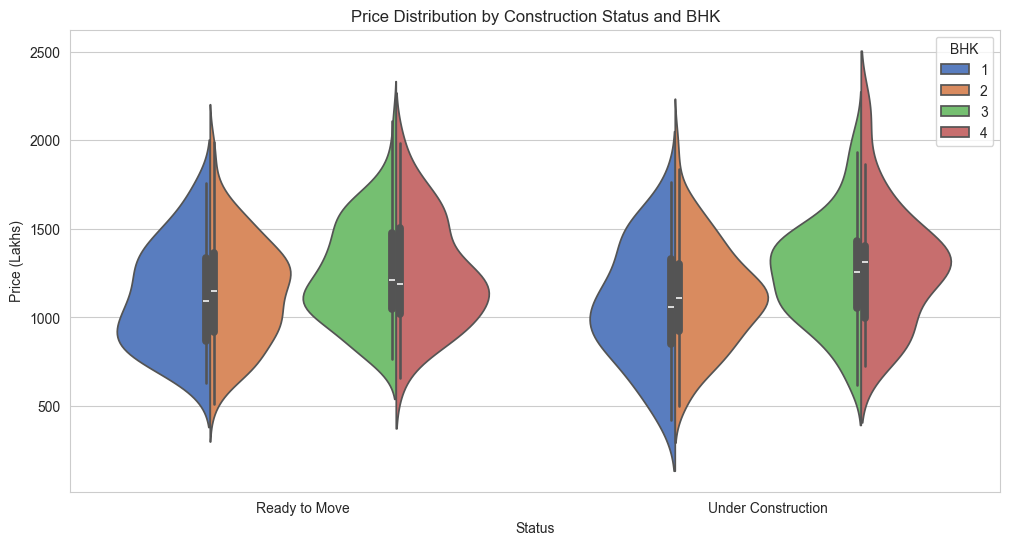

In [12]:
### Step 8: Advanced (but still easy!) – Violin Plot by Status
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Status', y='Price_Lakhs', 
               hue='BHK', split=True, palette='muted')
plt.title('Price Distribution by Construction Status and BHK')
plt.xlabel('Status')
plt.ylabel('Price (Lakhs)')
plt.show()

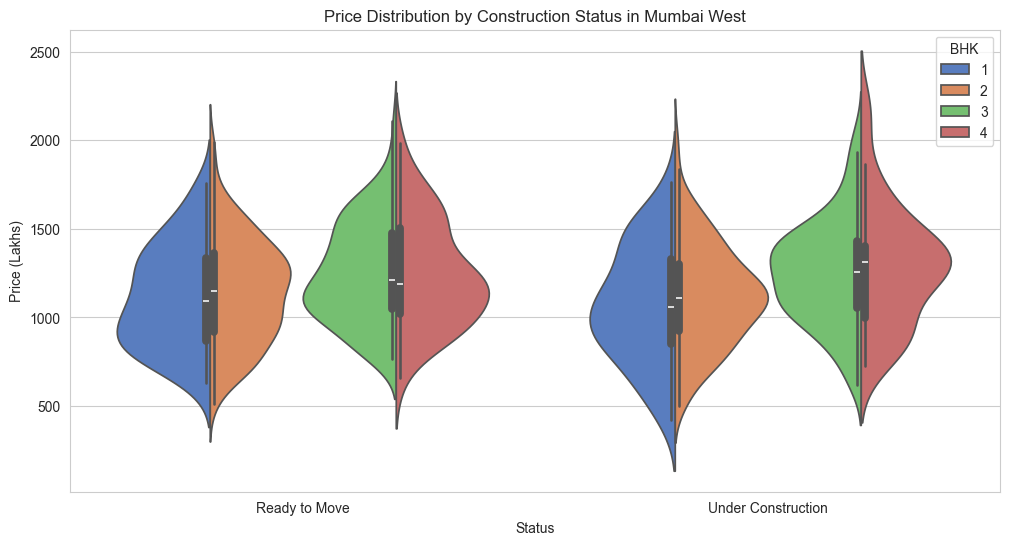

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, 
               x='Status',           # Groups: Ready vs Under Construction
               y='Price_Lakhs',      # What we are comparing: Price
               hue='BHK',            # Optional: color by number of bedrooms
               split=True,           # Nice split view
               palette='muted')

plt.title('Price Distribution by Construction Status in Mumbai West')
plt.xlabel('Status')
plt.ylabel('Price (Lakhs)')
plt.show()